In [1]:
!python --version


Python 3.13.13


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
import warnings

warnings.filterwarnings("ignore")

# Dark theme (slightly adjusted palette)
plt.rcParams.update({
    "figure.dpi": 125,
    "axes.facecolor": "#0f172a",
    "figure.facecolor": "#0f172a",
    "axes.edgecolor": "#334155",
    "axes.labelcolor": "#e2e8f0",
    "xtick.color": "#94a3b8",
    "ytick.color": "#94a3b8",
    "text.color": "#e2e8f0",
    "grid.color": "#1e293b",
    "grid.alpha": 0.45,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

RED = "#ef4444"; GREEN = "#22c55e"; BLUE = "#3b82f6"; AMBER = "#f59e0b"
PURPLE = "#a855f7"; TEAL = "#14b8a6"; GRAY = "#94a3b8"

# Keep path configurable so notebook runs outside Kaggle too
PATH = "Datasets/"

patients  = pd.read_csv(f"{PATH}patients.csv")
diagnoses = pd.read_csv(f"{PATH}diagnoses.csv", parse_dates=["visit_date"])
meds      = pd.read_csv(f"{PATH}medications.csv", parse_dates=["start_date"])
labs      = pd.read_csv(f"{PATH}lab_results.csv", parse_dates=["test_date"])
outcomes  = pd.read_csv(f"{PATH}outcomes.csv", parse_dates=["admission_date"])

dx_cols = [c for c in patients.columns if c.startswith("dx_")]
conditions = [c.replace("dx_", "") for c in dx_cols]

# --- Enhanced profile summary ---
n_patients = len(patients)
n_dx = len(diagnoses)
n_meds = len(meds)
n_labs = len(labs)
n_out = len(outcomes)

male_pct = (patients["sex"] == "M").mean() * 100
female_pct = (patients["sex"] == "F").mean() * 100

age_mean, age_std = patients["age"].mean(), patients["age"].std()
bmi_mean, bmi_std = patients["bmi"].mean(), patients["bmi"].std()

# Condition burden per patient
patients["condition_count"] = patients[dx_cols].sum(axis=1)
avg_conditions = patients["condition_count"].mean()
median_conditions = patients["condition_count"].median()

# Missingness
missing_pct = (patients.isna().mean() * 100).sort_values(ascending=False)
top_missing = missing_pct[missing_pct > 0].head(5)

# Most prevalent conditions
condition_prevalence = patients[dx_cols].mean().sort_values(ascending=False) * 100
top_conditions = condition_prevalence.head(5)

print(f"Patients: {n_patients:,}")
print(f"Diagnoses: {n_dx:,} | Medications: {n_meds:,} | Labs: {n_labs:,} | Admissions: {n_out:,}")
print(f"Tracked conditions: {len(conditions)}")
print()
print(f"Age (mean ± sd): {age_mean:.1f} ± {age_std:.1f} years")
print(f"BMI (mean ± sd): {bmi_mean:.1f} ± {bmi_std:.1f}")
print(f"Sex distribution: {male_pct:.1f}% male, {female_pct:.1f}% female")
print(f"Condition burden: mean={avg_conditions:.2f}, median={median_conditions:.0f} per patient")
print()

if not top_missing.empty:
    print("Top missing fields in patients table:")
    for col, pct in top_missing.items():
        print(f" - {col}: {pct:.2f}%")
    print()
else:
    print("No missing values detected in patients table.\n")

print("Top 5 prevalent conditions:")
for col, pct in top_conditions.items():
    print(f" - {col.replace('dx_', '')}: {pct:.1f}%")

# Optional: date coverage check
print("\n=== Time Coverage ===")
print(f"Diagnoses: {diagnoses['visit_date'].min().date()} to {diagnoses['visit_date'].max().date()}")
print(f"Medications: {meds['start_date'].min().date()} to {meds['start_date'].max().date()}")
print(f"Labs: {labs['test_date'].min().date()} to {labs['test_date'].max().date()}")
print(f"Admissions: {outcomes['admission_date'].min().date()} to {outcomes['admission_date'].max().date()}")

Patients: 100,000
Diagnoses: 274,592 | Medications: 364,174 | Labs: 2,827,722 | Admissions: 11,001
Tracked conditions: 15

Age (mean ± sd): 71.6 ± 17.3 years
BMI (mean ± sd): 27.5 ± 5.4
Sex distribution: 49.3% male, 50.7% female
Condition burden: mean=3.06, median=3 per patient

No missing values detected in patients table.

Top 5 prevalent conditions:
 - hypertension: 67.7%
 - obesity: 60.3%
 - hyperlipidemia: 54.5%
 - chronic_kidney_disease: 21.5%
 - osteoarthritis: 18.6%

=== Time Coverage ===
Diagnoses: 2018-01-01 to 2024-12-30
Medications: 2018-01-01 to 2021-07-01
Labs: 2018-01-01 to 2024-12-30
Admissions: 2018-01-01 to 2024-12-30


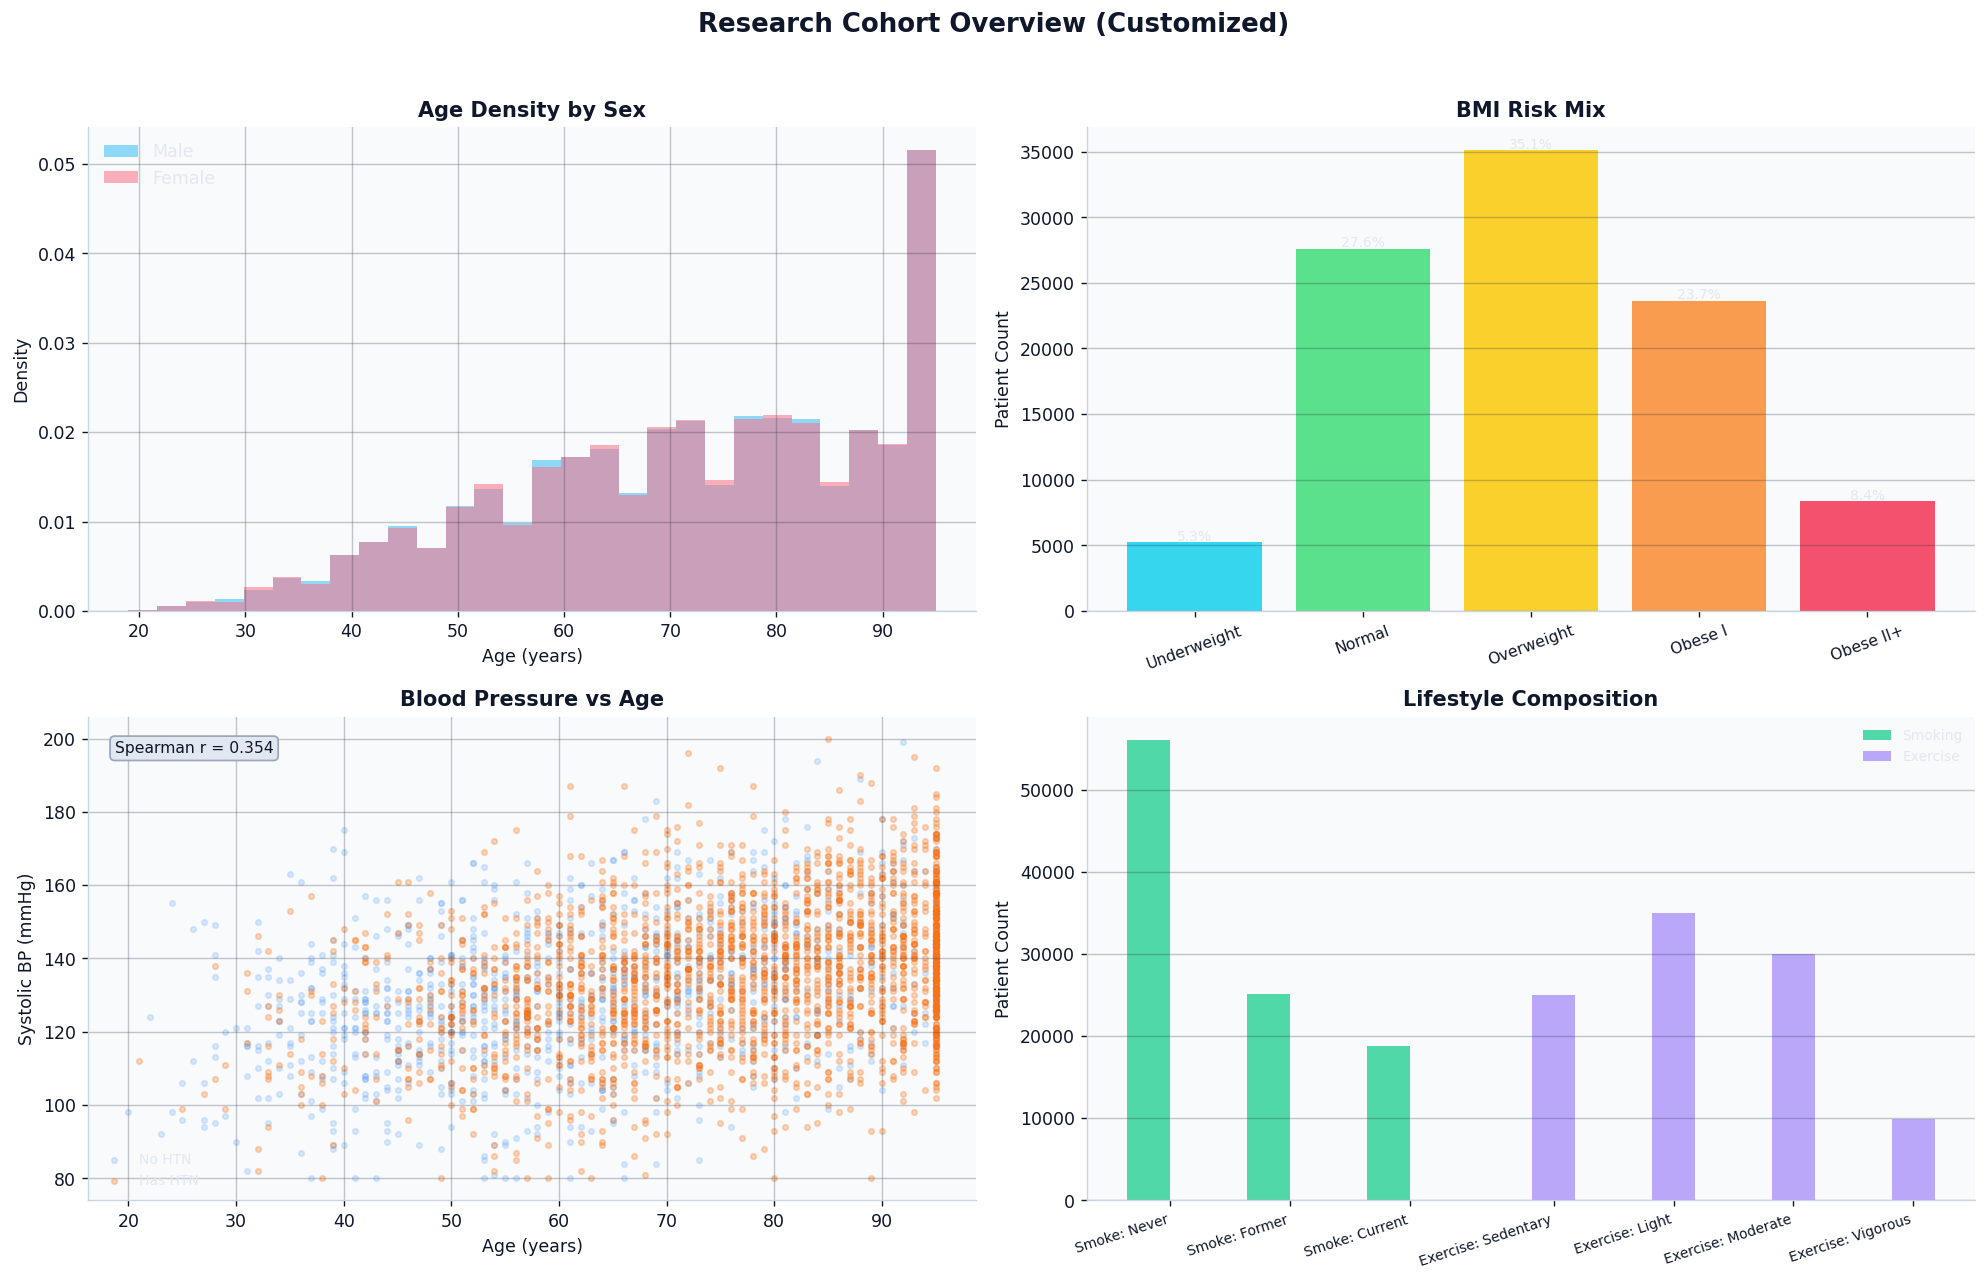

In [ ]:
palette = {
    "male": "#38bdf8",
    "female": "#fb7185",
    "bmi": ["#22d3ee", "#4ade80", "#facc15", "#fb923c", "#f43f5e"],
    "bp_norm": "#60a5fa",
    "bp_htn": "#f97316",
    "smoking": "#34d399",
    "exercise": "#a78bfa",
}

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.patch.set_facecolor("#ffffff")

for ax in axes.flat:
    ax.set_facecolor("#f8fafc")
    ax.tick_params(colors="#0f172a")
    ax.xaxis.label.set_color("#0f172a")
    ax.yaxis.label.set_color("#0f172a")
    ax.title.set_color("#0f172a")
    for spine in ax.spines.values():
        spine.set_color("#cbd5e1")

ax = axes[0, 0]
for sex_code, color, label in [("M", palette["male"], "Male"), ("F", palette["female"], "Female")]:
    age_slice = patients.loc[patients["sex"] == sex_code, "age"]
    ax.hist(age_slice, bins=28, density=True, alpha=0.55, color=color, label=label)

ax.set_title("Age Density by Sex", fontsize=12, fontweight="bold")
ax.set_xlabel("Age (years)")
ax.set_ylabel("Density")
ax.legend(frameon=False)
ax.grid(True, alpha=0.25)

ax = axes[0, 1]
bmi_labels = ["Underweight", "Normal", "Overweight", "Obese I", "Obese II+"]
bmi_bins = [0, 18.5, 25, 30, 35, 100]

bmi_classes = pd.cut(patients["bmi"], bins=bmi_bins, labels=bmi_labels, include_lowest=True)
bmi_counts = bmi_classes.value_counts().reindex(bmi_labels).fillna(0)

bars = ax.bar(bmi_labels, bmi_counts.values, color=palette["bmi"], alpha=0.9)
ax.set_title("BMI Risk Mix", fontsize=12, fontweight="bold")
ax.set_ylabel("Patient Count")
ax.tick_params(axis="x", rotation=20, labelsize=9)
ax.grid(True, axis="y", alpha=0.25)

for bar, count in zip(bars, bmi_counts.values):
    pct = count / len(patients)
    ax.text(bar.get_x() + bar.get_width() / 2, count + 120, f"{pct:.1%}", ha="center", fontsize=8)


ax = axes[1, 0]
scatter_n = min(3500, len(patients))
sample = patients.sample(scatter_n, random_state=77)

has_htn = sample["dx_hypertension"] == 1
ax.scatter(sample.loc[~has_htn, "age"], sample.loc[~has_htn, "systolic_bp"],
           s=10, alpha=0.22, color=palette["bp_norm"], label="No HTN")
ax.scatter(sample.loc[has_htn, "age"], sample.loc[has_htn, "systolic_bp"],
           s=10, alpha=0.28, color=palette["bp_htn"], label="Has HTN")

corr = stats.spearmanr(patients["age"], patients["systolic_bp"])[0]
ax.set_title("Blood Pressure vs Age", fontsize=12, fontweight="bold")
ax.set_xlabel("Age (years)")
ax.set_ylabel("Systolic BP (mmHg)")
ax.grid(True, alpha=0.25)
ax.legend(frameon=False, fontsize=8)
ax.text(0.03, 0.95, f"Spearman r = {corr:.3f}", transform=ax.transAxes, va="top",
        fontsize=9, color="#0f172a",
        bbox=dict(boxstyle="round", facecolor="#e2e8f0", edgecolor="#94a3b8", alpha=0.95))


ax = axes[1, 1]
smoking_order = ["never", "former", "current"]
exercise_order = ["sedentary", "light", "moderate", "vigorous"]

smoking_counts = patients["smoking_status"].value_counts().reindex(smoking_order).fillna(0)
exercise_counts = patients["exercise_level"].value_counts().reindex(exercise_order).fillna(0)

x_sm = np.arange(len(smoking_order))
x_ex = np.arange(len(exercise_order))

ax.bar(x_sm - 0.18, smoking_counts.values, width=0.36, color=palette["smoking"], alpha=0.85, label="Smoking")
ax.bar(x_ex + 3.2, exercise_counts.values, width=0.36, color=palette["exercise"], alpha=0.75, label="Exercise")

combined_ticks = list(x_sm) + list(x_ex + 3.2)
combined_labels = [f"Smoke: {s.title()}" for s in smoking_order] + [f"Exercise: {e.title()}" for e in exercise_order]
ax.set_xticks(combined_ticks)
ax.set_xticklabels(combined_labels, rotation=18, ha="right", fontsize=8)
ax.set_ylabel("Patient Count")
ax.set_title("Lifestyle Composition", fontsize=12, fontweight="bold")
ax.grid(True, axis="y", alpha=0.25)
ax.legend(frameon=False, fontsize=8, loc="upper right")

plt.suptitle("Research Cohort Overview (Customized)", fontsize=15, fontweight="bold", y=1.02, color="#0f172a")
plt.tight_layout()
plt.savefig("population_overview_custom.png", dpi=140, bbox_inches="tight", facecolor="#ffffff")
plt.show()

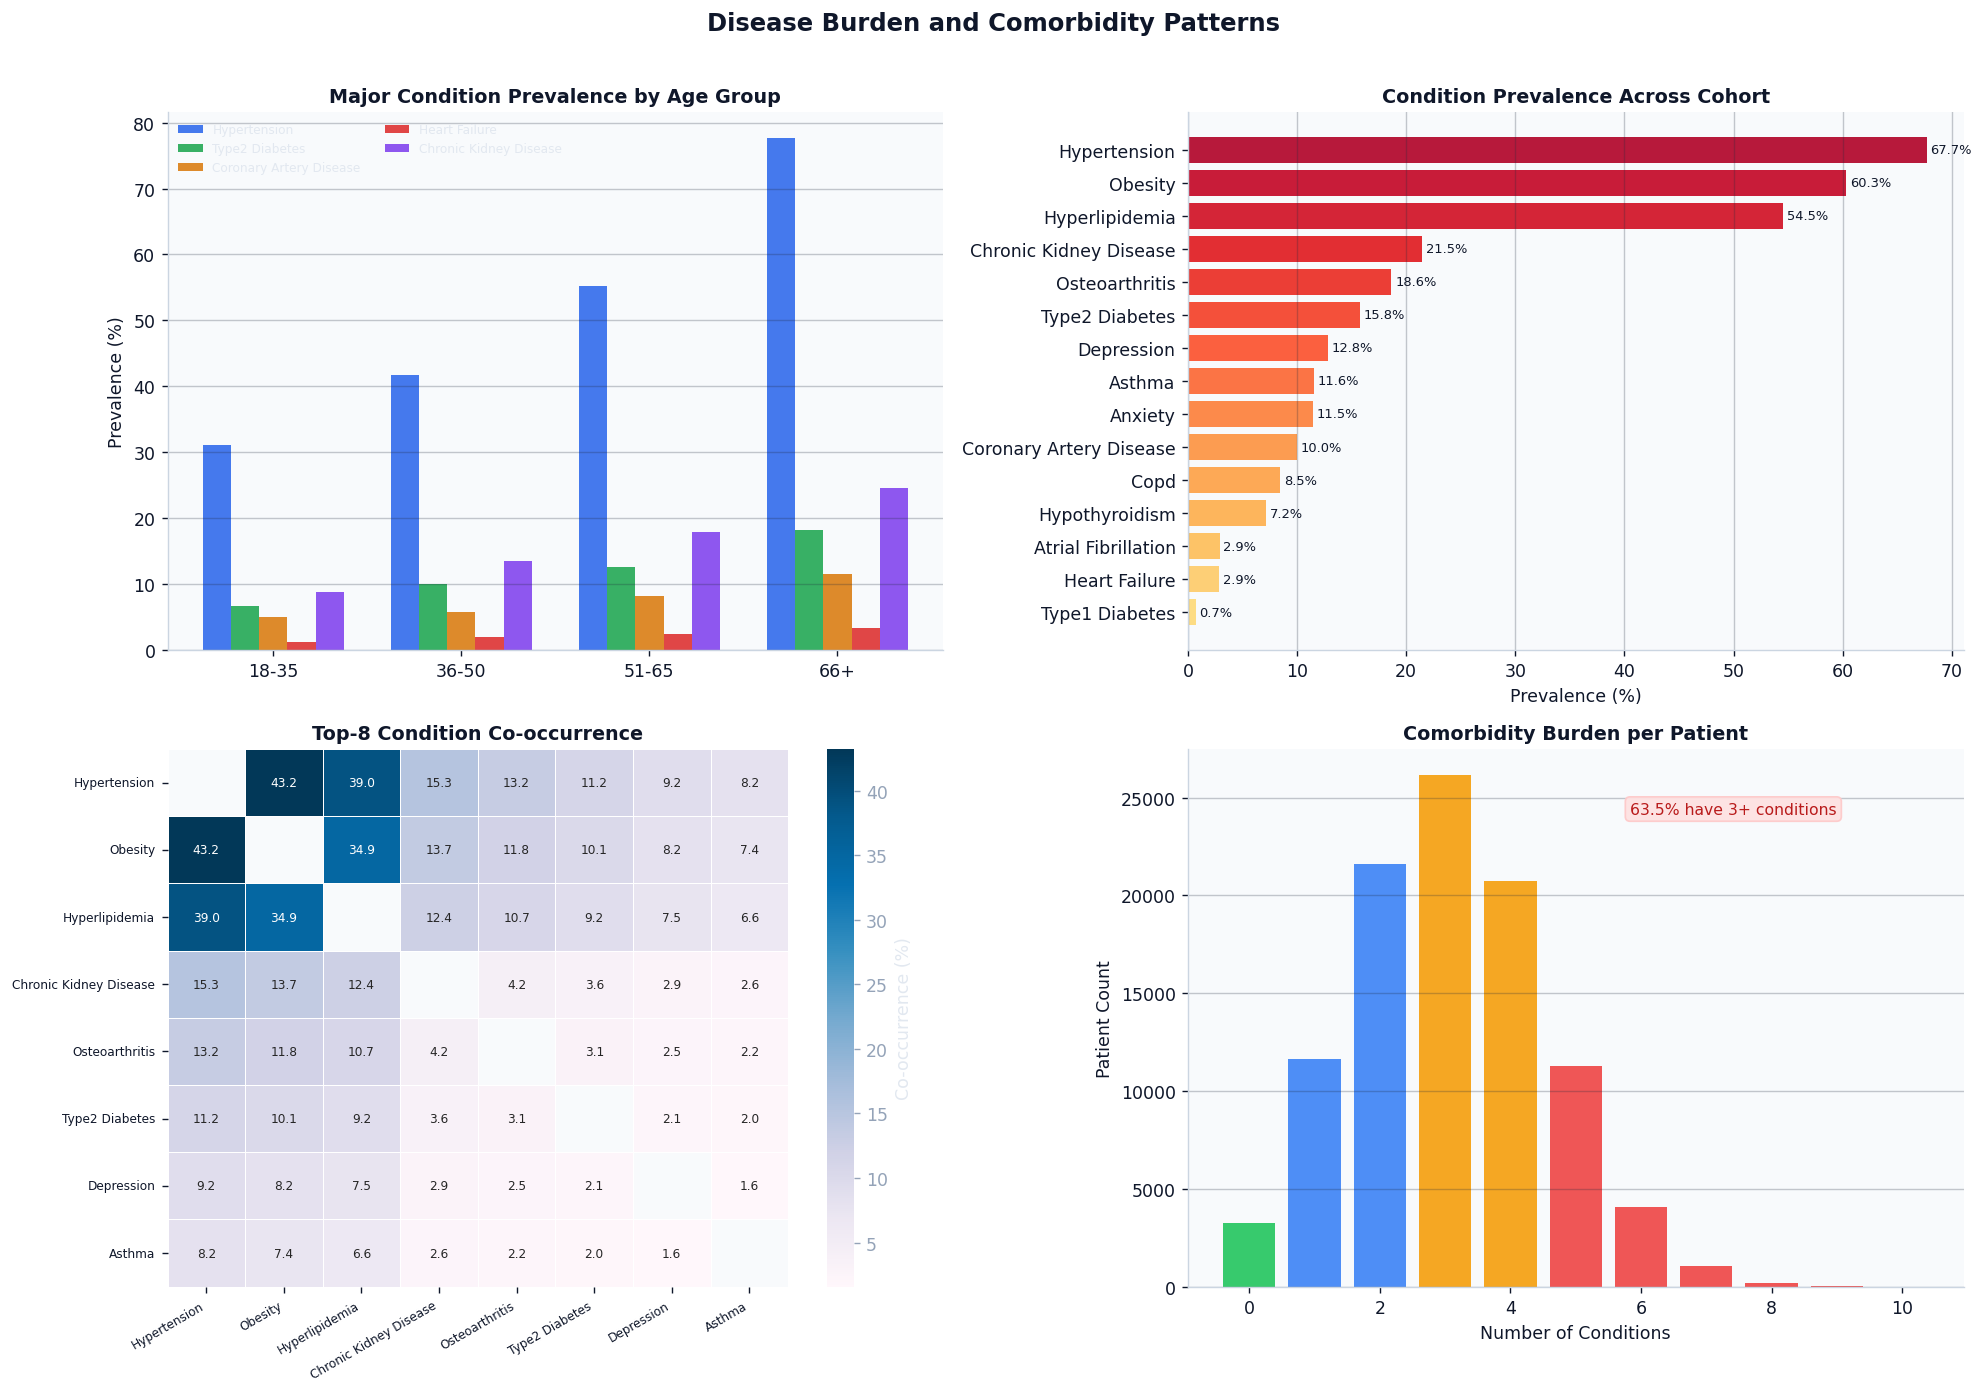

In [ ]:

fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.patch.set_facecolor("#ffffff")

for ax in axes.flat:
    ax.set_facecolor("#f8fafc")
    ax.tick_params(colors="#0f172a")
    ax.xaxis.label.set_color("#0f172a")
    ax.yaxis.label.set_color("#0f172a")
    ax.title.set_color("#0f172a")
    for spine in ax.spines.values():
        spine.set_color("#cbd5e1")


ax = axes[0, 0]
age_bins = [17, 35, 50, 65, 100]
age_labels = ["18-35", "36-50", "51-65", "66+"]
plot_df = patients.copy()
plot_df["age_group"] = pd.cut(plot_df["age"], bins=age_bins, labels=age_labels)

major_conditions = [
    "dx_hypertension",
    "dx_type2_diabetes",
    "dx_coronary_artery_disease",
    "dx_heart_failure",
    "dx_chronic_kidney_disease",
]

age_prev = plot_df.groupby("age_group", observed=True)[major_conditions].mean() * 100
age_colors = ["#2563eb", "#16a34a", "#d97706", "#dc2626", "#7c3aed"]
x = np.arange(len(age_labels))
width = 0.15

for i, (col, color) in enumerate(zip(major_conditions, age_colors)):
    ax.bar(x + i * width, age_prev[col].values, width=width, color=color, alpha=0.85,
           label=col.replace("dx_", "").replace("_", " ").title())

ax.set_xticks(x + 2 * width)
ax.set_xticklabels(age_labels)
ax.set_title("Major Condition Prevalence by Age Group", fontsize=11, fontweight="bold")
ax.set_ylabel("Prevalence (%)")
ax.grid(True, axis="y", alpha=0.25)
ax.legend(fontsize=7, ncol=2, frameon=False)


ax = axes[0, 1]
prev = plot_df[dx_cols].mean().sort_values(ascending=True) * 100
prev_labels = [c.replace("dx_", "").replace("_", " ").title() for c in prev.index]
prev_colors = plt.cm.YlOrRd(np.linspace(0.25, 0.9, len(prev)))

ax.barh(prev_labels, prev.values, color=prev_colors, alpha=0.9)
ax.set_title("Condition Prevalence Across Cohort", fontsize=11, fontweight="bold")
ax.set_xlabel("Prevalence (%)")
ax.grid(True, axis="x", alpha=0.25)

for i, val in enumerate(prev.values):
    ax.text(val + 0.35, i, f"{val:.1f}%", va="center", fontsize=7.5, color="#0f172a")


ax = axes[1, 0]
top8 = plot_df[dx_cols].mean().nlargest(8).index.tolist()
co_matrix = plot_df[top8].T.dot(plot_df[top8]) / len(plot_df) * 100
heat_labels = [c.replace("dx_", "").replace("_", " ").title() for c in top8]

diag_mask = np.eye(len(top8), dtype=bool)
co_display = co_matrix.mask(diag_mask)

sns.heatmap(
    co_display,
    annot=True,
    fmt=".1f",
    cmap="PuBu",
    xticklabels=heat_labels,
    yticklabels=heat_labels,
    linewidths=0.4,
    ax=ax,
    cbar_kws={"label": "Co-occurrence (%)"},
    annot_kws={"size": 7},
)

ax.set_title("Top-8 Condition Co-occurrence", fontsize=11, fontweight="bold")
plt.setp(ax.get_xticklabels(), fontsize=7, rotation=30, ha="right", color="#0f172a")
plt.setp(ax.get_yticklabels(), fontsize=7, color="#0f172a")

ax = axes[1, 1]
condition_count = plot_df[dx_cols].sum(axis=1)
burden_dist = condition_count.value_counts().sort_index()

bar_colors = ["#22c55e" if x == 0 else "#3b82f6" if x <= 2 else "#f59e0b" if x <= 4 else "#ef4444"
              for x in burden_dist.index]
ax.bar(burden_dist.index, burden_dist.values, color=bar_colors, alpha=0.9)
ax.set_title("Comorbidity Burden per Patient", fontsize=11, fontweight="bold")
ax.set_xlabel("Number of Conditions")
ax.set_ylabel("Patient Count")
ax.grid(True, axis="y", alpha=0.25)

pct_multi = (condition_count >= 3).mean()
ax.text(
    0.57,
    0.88,
    f"{pct_multi:.1%} have 3+ conditions",
    transform=ax.transAxes,
    fontsize=9,
    color="#b91c1c",
    bbox=dict(boxstyle="round", facecolor="#fee2e2", edgecolor="#fecaca", alpha=0.95),
)

plt.suptitle("Disease Burden and Comorbidity Patterns", fontsize=14, fontweight="bold", y=1.01, color="#0f172a")
plt.tight_layout()
plt.savefig("comorbidity_custom.png", dpi=140, bbox_inches="tight", facecolor="#ffffff")
plt.show()

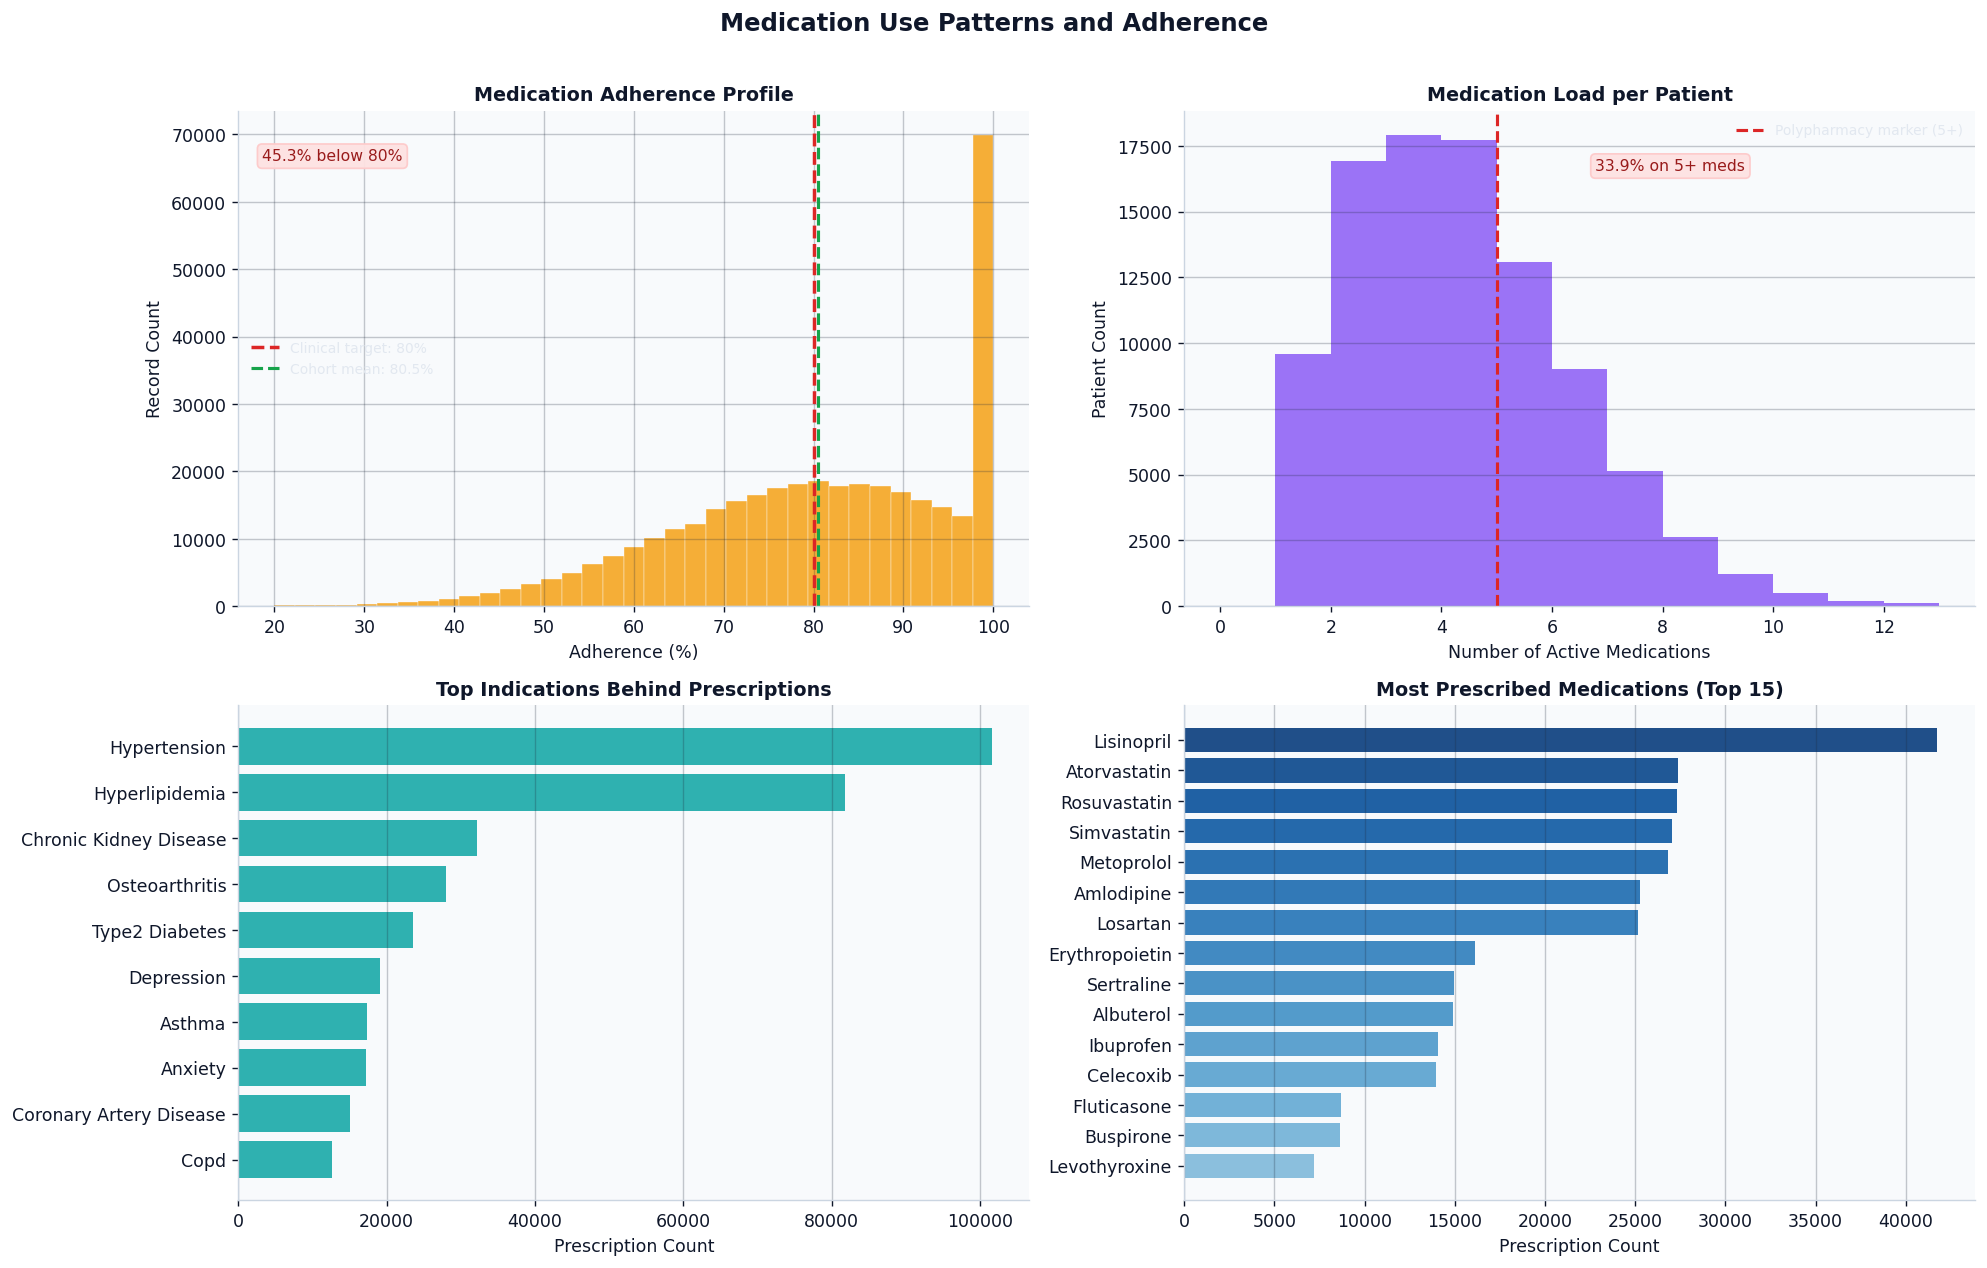

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.patch.set_facecolor("#ffffff")

for ax in axes.flat:
    ax.set_facecolor("#f8fafc")
    ax.tick_params(colors="#0f172a")
    ax.xaxis.label.set_color("#0f172a")
    ax.yaxis.label.set_color("#0f172a")
    ax.title.set_color("#0f172a")
    for spine in ax.spines.values():
        spine.set_color("#cbd5e1")

ax = axes[0, 0]
adherence_vals = meds["adherence_pct"].dropna()
ax.hist(adherence_vals, bins=35, color="#f59e0b", alpha=0.82, edgecolor="#ffffff", linewidth=0.25)
ax.axvline(80, color="#dc2626", linewidth=2, linestyle="--", label="Clinical target: 80%")
ax.axvline(adherence_vals.mean(), color="#16a34a", linewidth=1.8, linestyle="--",
           label=f"Cohort mean: {adherence_vals.mean():.1f}%")
ax.set_title("Medication Adherence Profile", fontsize=11, fontweight="bold")
ax.set_xlabel("Adherence (%)")
ax.set_ylabel("Record Count")
ax.grid(True, alpha=0.25)
ax.legend(fontsize=8, frameon=False)

pct_low = (adherence_vals < 80).mean()
ax.text(
    0.03,
    0.9,
    f"{pct_low:.1%} below 80%",
    transform=ax.transAxes,
    fontsize=9,
    color="#991b1b",
    bbox=dict(boxstyle="round", facecolor="#fee2e2", edgecolor="#fecaca", alpha=0.95),
)

ax = axes[0, 1]
meds_per_patient = meds.groupby("patient_id").size()
ax.hist(meds_per_patient.clip(0, 12), bins=13, range=(0, 13), color="#8b5cf6", alpha=0.85)
ax.axvline(5, color="#dc2626", linewidth=1.8, linestyle="--", label="Polypharmacy marker (5+)")
ax.set_title("Medication Load per Patient", fontsize=11, fontweight="bold")
ax.set_xlabel("Number of Active Medications")
ax.set_ylabel("Patient Count")
ax.grid(True, axis="y", alpha=0.25)
ax.legend(fontsize=8, frameon=False)

poly_pct = (meds_per_patient >= 5).mean()
ax.text(
    0.52,
    0.88,
    f"{poly_pct:.1%} on 5+ meds",
    transform=ax.transAxes,
    fontsize=9,
    color="#991b1b",
    bbox=dict(boxstyle="round", facecolor="#fee2e2", edgecolor="#fecaca", alpha=0.95),
)

ax = axes[1, 0]
indication_counts = meds["indication"].value_counts().head(10).sort_values(ascending=True)
indication_labels = [label.replace("_", " ").title() for label in indication_counts.index]
ax.barh(indication_labels, indication_counts.values, color="#0ea5a4", alpha=0.86)
ax.set_title("Top Indications Behind Prescriptions", fontsize=11, fontweight="bold")
ax.set_xlabel("Prescription Count")
ax.grid(True, axis="x", alpha=0.25)


ax = axes[1, 1]
top_meds = meds["medication"].value_counts().head(15).sort_values(ascending=True)
med_colors = plt.cm.Blues(np.linspace(0.45, 0.95, len(top_meds)))
ax.barh(top_meds.index, top_meds.values, color=med_colors, alpha=0.9)
ax.set_title("Most Prescribed Medications (Top 15)", fontsize=11, fontweight="bold")
ax.set_xlabel("Prescription Count")
ax.grid(True, axis="x", alpha=0.25)

plt.suptitle("Medication Use Patterns and Adherence", fontsize=14, fontweight="bold", y=1.01, color="#0f172a")
plt.tight_layout()
plt.savefig("medications_custom.png", dpi=140, bbox_inches="tight", facecolor="#ffffff")
plt.show()